# Proyecto final: agrupamiento no supervisado de perfiles sensoriales de café

**Módulo:** Aprendizaje No Supervisado  
**Estudiante:** Nuvia Meza  
**Dataset:** Coffee Quality Institute (CQI) - Arabica Coffee Quality Data

## Resumen

Este proyecto estudia si los lotes de café arábica pueden agruparse según sus perfiles sensoriales sin utilizar etiquetas de calidad durante el entrenamiento. Se comparan tres algoritmos: **Modelos de Mezclas Gaussianas (GMM)**, **Clustering Jerárquico Aglomerativo** y **Clustering Espectral**.

El proceso incluye análisis exploratorio, control de calidad de datos, selección y estandarización de variables, optimización de hiperparámetros, evaluación con métricas internas, visualización mediante PCA y Isomap, análisis de concordancia entre algoritmos e interpretación de los grupos obtenidos.

## 1. Planteamiento del problema y objetivos

Las puntuaciones de cata describen distintas dimensiones del perfil de un café, como aroma, sabor, acidez, cuerpo y balance. Aunque la calificación total resume parcialmente estas dimensiones, puede ocultar estructuras internas y perfiles sensoriales recurrentes.

**Objetivo general:** identificar grupos naturales de cafés con perfiles sensoriales similares y determinar qué algoritmo produce la partición más coherente y útil para interpretar la calidad.

**Objetivos específicos:**

1. Analizar la calidad, distribución, correlación y presencia de valores atípicos en los datos.
2. Seleccionar variables apropiadas para clustering y justificar el preprocesamiento.
3. Optimizar y comparar GMM, clustering jerárquico y clustering espectral.
4. Evaluar las soluciones con Silhouette, Calinski-Harabasz y Davies-Bouldin.
5. Interpretar los clústeres mediante perfiles promedio, puntuación total y país de origen.

## 2. Configuración del entorno

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import kruskal

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## 3. Dataset y carga reproducible

Se utiliza la versión pública del conjunto **Arabica Coffee Quality Data**, distribuida en el repositorio *Coffee Quality Database*. Cada fila representa un lote de café evaluado por el protocolo de cata del CQI.

La celda siguiente intenta usar primero una copia local del CSV y, si no existe, lo descarga automáticamente desde GitHub. De esta forma, el notebook puede ejecutarse tanto localmente como en Google Colab.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/jldbc/coffee-quality-database/master/data/arabica_data_cleaned.csv"
local_candidates = [
    Path("arabica_data_cleaned.csv"),
    Path("/mnt/data/arabica_data_cleaned.csv"),
]

local_path = next((p for p in local_candidates if p.exists()), None)

if local_path is not None:
    df_raw = pd.read_csv(local_path)
    data_origin = f"archivo local: {local_path}"
else:
    df_raw = pd.read_csv(DATA_URL)
    data_origin = DATA_URL

print(f"Origen utilizado: {data_origin}")
print(f"Dimensiones originales: {df_raw.shape[0]} filas y {df_raw.shape[1]} columnas")
display(df_raw.head(3))

Origen utilizado: https://raw.githubusercontent.com/jldbc/coffee-quality-database/master/data/arabica_data_cleaned.csv
Dimensiones originales: 1311 filas y 44 columnas


,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,Region,Producer,Number.of.Bags,Bag.Weight,In.Country.Partner,Harvest.Year,Grading.Date,Owner.1,Variety,Processing.Method,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,NaN,Washed / Wet,8.670,8.830,8.670,8.750,8.500,8.420,10.000,10.000,10.000,8.750,90.580,0.120,0,0.000,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.000,2200.000,2075.000
1,2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,Washed / Wet,8.750,8.670,8.500,8.580,8.420,8.420,10.000,10.000,10.000,8.580,89.920,0.120,0,0.000,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.000,2200.000,2075.000
2,3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,NaN,5,1,Specialty Coffee Association,NaN,"May 31st, 2010",Grounds for Health Admin,Bourbon,NaN,8.420,8.500,8.420,8.420,8.330,8.420,10.000,10.000,10.000,9.250,89.750,0.000,0,0.000,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.000,1800.000,1700.000


## 4. Calidad de datos y preparación inicial

In [3]:
all_sensory_features = [
    "Aroma", "Flavor", "Aftertaste", "Acidity", "Body", "Balance",
    "Uniformity", "Clean.Cup", "Sweetness"
]
context_features = [
    "Country.of.Origin", "Variety", "Processing.Method", "Total.Cup.Points"
]
selected_columns = all_sensory_features + context_features

quality_report = pd.DataFrame({
    "tipo": df_raw[selected_columns].dtypes.astype(str),
    "faltantes": df_raw[selected_columns].isna().sum(),
    "porcentaje_faltante": df_raw[selected_columns].isna().mean() * 100,
    "valores_unicos": df_raw[selected_columns].nunique(dropna=True),
})

display(quality_report)
print(f"Filas duplicadas considerando las variables seleccionadas: {df_raw[selected_columns].duplicated().sum()}")

,tipo,faltantes,porcentaje_faltante,valores_unicos
Aroma,float64,0,0.000,33
Flavor,float64,0,0.000,35
Aftertaste,float64,0,0.000,35
Acidity,float64,0,0.000,31
Body,float64,0,0.000,31
Balance,float64,0,0.000,32
Uniformity,float64,0,0.000,10
Clean.Cup,float64,0,0.000,11
Sweetness,float64,0,0.000,8
Country.of.Origin,object,1,0.076,36


Filas duplicadas considerando las variables seleccionadas: 1


In [4]:
# Las variables sensoriales y Total.Cup.Points no presentan faltantes.
# Los faltantes categóricos se conservan como una categoría explícita,
# porque esas variables se utilizarán sólo para interpretación posterior.
df = df_raw[selected_columns].copy()
for col in ["Country.of.Origin", "Variety", "Processing.Method"]:
    df[col] = df[col].fillna("Unknown")

rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_removed = rows_before - len(df)

print(f"Observaciones disponibles para el análisis: {len(df)}")
print(f"Duplicados eliminados: {rows_removed}")
print(f"Faltantes restantes: {int(df.isna().sum().sum())}")

Observaciones disponibles para el análisis: 1310
Duplicados eliminados: 1
Faltantes restantes: 0


**Decisión de calidad de datos.** No se eliminan filas por valores faltantes en `Variety` o `Processing.Method`, porque estas columnas no intervienen en el clustering. Eliminarlas habría reducido innecesariamente el tamaño de la muestra. Los faltantes categóricos se codifican como `Unknown` y se conserva toda la información sensorial disponible.

## 5. Análisis exploratorio de datos

In [5]:
descriptive_stats = df[all_sensory_features + ["Total.Cup.Points"]].describe().T

descriptive_stats["IQR"] = descriptive_stats["75%"] - descriptive_stats["25%"]
descriptive_stats["coef_variacion"] = descriptive_stats["std"] / descriptive_stats["mean"]
display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max,IQR,coef_variacion
Aroma,1310.000,7.564,0.379,0.000,7.420,7.580,7.750,8.750,0.330,0.050
Flavor,1310.000,7.518,0.400,0.000,7.330,7.580,7.750,8.830,0.420,0.053
Aftertaste,1310.000,7.398,0.405,0.000,7.250,7.420,7.580,8.670,0.330,0.055
Acidity,1310.000,7.533,0.382,0.000,7.330,7.500,7.750,8.750,0.420,0.051
Body,1310.000,7.518,0.359,0.000,7.330,7.500,7.670,8.580,0.340,0.048
Balance,1310.000,7.518,0.406,0.000,7.330,7.500,7.750,8.750,0.420,0.054
Uniformity,1310.000,9.833,0.560,0.000,10.000,10.000,10.000,10.000,0.000,0.057
Clean.Cup,1310.000,9.833,0.772,0.000,10.000,10.000,10.000,10.000,0.000,0.078
Sweetness,1310.000,9.903,0.531,0.000,10.000,10.000,10.000,10.000,0.000,0.054
Total.Cup.Points,1310.000,82.117,3.517,0.000,81.170,82.500,83.670,90.580,2.500,0.043


### 5.1. Distribuciones sensoriales

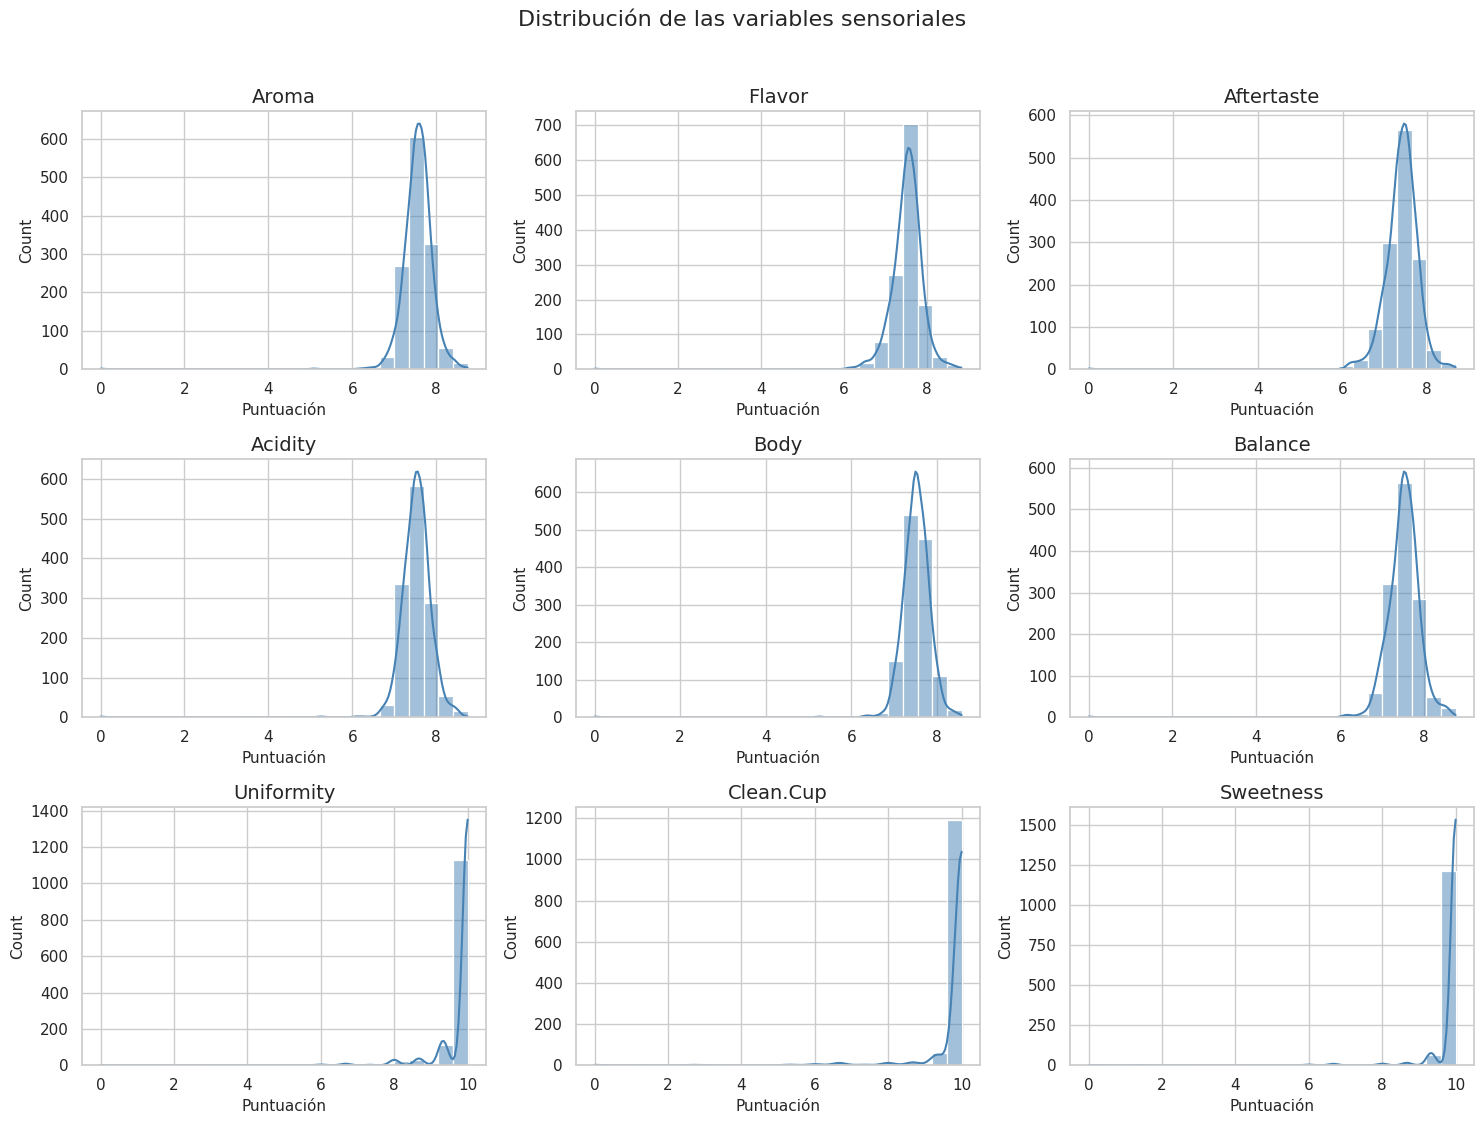

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()

for ax, col in zip(axes, all_sensory_features):
    sns.histplot(df[col], kde=True, bins=25, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("Puntuación")

plt.suptitle("Distribución de las variables sensoriales", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
ceiling_report = pd.DataFrame({
    "porcentaje_igual_a_10": [100 * (df[c] == 10).mean() for c in all_sensory_features],
    "IQR": [df[c].quantile(0.75) - df[c].quantile(0.25) for c in all_sensory_features],
    "desviacion_estandar": [df[c].std() for c in all_sensory_features],
}, index=all_sensory_features).sort_values("porcentaje_igual_a_10", ascending=False)

display(ceiling_report)

,porcentaje_igual_a_10,IQR,desviacion_estandar
Sweetness,92.901,0.000,0.531
Clean.Cup,91.069,0.000,0.772
Uniformity,86.031,0.000,0.560
Aroma,0.000,0.330,0.379
Flavor,0.000,0.420,0.400
Body,0.000,0.340,0.359
Acidity,0.000,0.420,0.382
Aftertaste,0.000,0.330,0.405
Balance,0.000,0.420,0.406


Las variables `Uniformity`, `Clean.Cup` y `Sweetness` presentan un fuerte **efecto techo**: la gran mayoría de sus observaciones es exactamente 10 y su rango intercuartílico es cero. Incluirlas en las distancias puede hacer que pequeñas desviaciones respecto de 10 dominen artificialmente la formación de clústeres. Por este motivo se conservarán para la interpretación, pero no serán variables de entrada del clustering.

### 5.2. Valores atípicos

In [8]:
outlier_rows = []
for col in all_sensory_features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": lower,
        "limite_superior": upper,
        "n_outliers_IQR": int(n_outliers),
        "porcentaje": 100 * n_outliers / len(df),
    })

outlier_report = pd.DataFrame(outlier_rows).set_index("variable")
display(outlier_report)

,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers_IQR,porcentaje
variable,,,,,,,
Aroma,7.420,7.750,0.330,6.925,8.245,70,5.344
Flavor,7.330,7.750,0.420,6.700,8.380,43,3.282
Aftertaste,7.250,7.580,0.330,6.755,8.075,85,6.489
Acidity,7.330,7.750,0.420,6.700,8.380,25,1.908
Body,7.330,7.670,0.340,6.820,8.180,30,2.290
Balance,7.330,7.750,0.420,6.700,8.380,39,2.977
Uniformity,10.000,10.000,0.000,10.000,10.000,183,13.969
Clean.Cup,10.000,10.000,0.000,10.000,10.000,117,8.931
Sweetness,10.000,10.000,0.000,10.000,10.000,93,7.099


Los valores atípicos de las seis variables principales corresponden principalmente a lotes con puntuaciones sensoriales bajas, pero todavía dentro de la escala válida de cata. No se eliminan porque constituyen información relevante sobre cafés menos consistentes. En las variables con IQR igual a cero, cualquier valor menor que 10 es marcado por la regla IQR; esto refleja el efecto techo y no necesariamente un error de medición.

### 5.3. Correlaciones

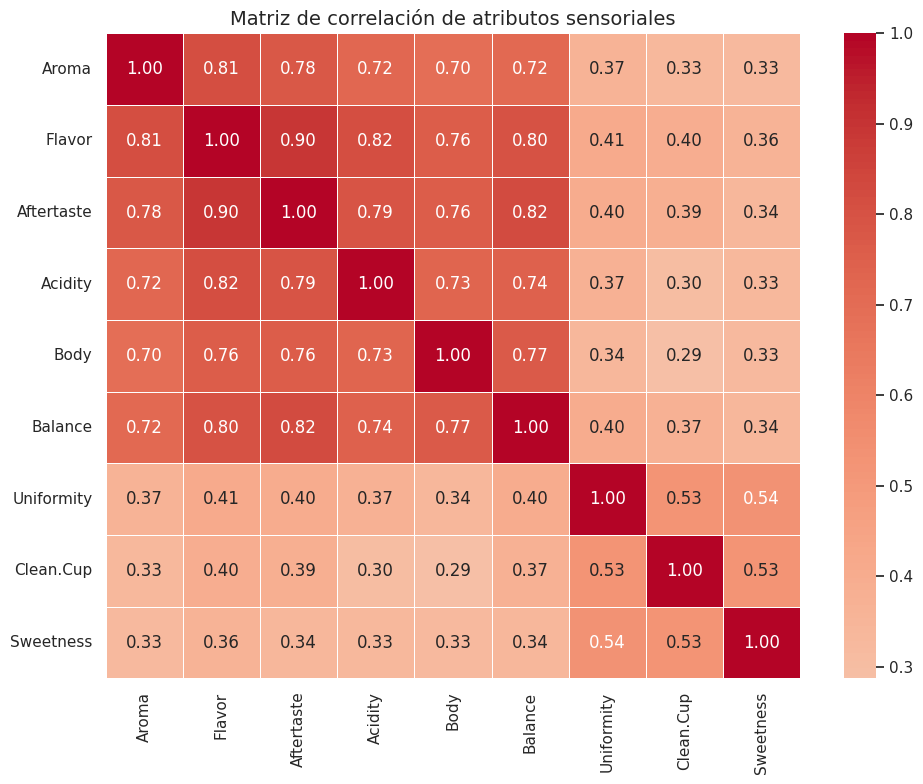

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[all_sensory_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("Matriz de correlación de atributos sensoriales")
plt.tight_layout()
plt.show()

`Flavor`, `Aftertaste`, `Balance`, `Aroma` y `Acidity` presentan correlaciones positivas importantes. Esto indica que la estructura no es esférica ni completamente independiente. Por ello resulta pertinente comparar un modelo probabilístico con covarianzas ajustables, un método jerárquico basado en Ward y un método espectral capaz de trabajar con relaciones locales.

## 6. Selección de variables y preprocesamiento

In [10]:
# Variables empleadas para formar los clústeres.
core_features = ["Aroma", "Flavor", "Aftertaste", "Acidity", "Body", "Balance"]

# Variables reservadas para interpretación y validación posterior.
contextual_quality_features = ["Uniformity", "Clean.Cup", "Sweetness", "Total.Cup.Points"]

X = df[core_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaling_check = pd.DataFrame(X_scaled, columns=core_features).agg(["mean", "std"]).T
print("Variables de entrada:", core_features)
print("Forma de la matriz:", X_scaled.shape)
display(scaling_check)

Variables de entrada: ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']
Forma de la matriz: (1310, 6)


,mean,std
Aroma,0.000,1.000
Flavor,0.000,1.000
Aftertaste,-0.000,1.000
Acidity,-0.000,1.000
Body,0.000,1.000
Balance,-0.000,1.000


**Justificación.** Se utiliza `StandardScaler` porque los algoritmos comparados dependen de distancias, covarianzas o similitudes. Aunque las variables originales comparten una escala similar, sus dispersiones no son idénticas. La estandarización evita que una dimensión con mayor varianza tenga un peso desproporcionado. `Total.Cup.Points` no se utiliza como entrada porque es una puntuación agregada derivada de los atributos de cata; se reserva como validación contextual para evitar duplicar información.

## 7. Funciones de evaluación y criterio de selección

In [11]:
def evaluate_partition(X_data, labels):
    '''Calcula métricas internas y tamaños de clúster.'''
    counts = np.bincount(labels)
    return {
        "Silhouette": silhouette_score(X_data, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_data, labels),
        "Davies_Bouldin": davies_bouldin_score(X_data, labels),
        "Min_Cluster_Size": int(counts.min()),
        "Max_Cluster_Size": int(counts.max()),
        "Cluster_Sizes": tuple(int(v) for v in counts),
    }


def add_composite_rank(results, include_bic=False):
    '''Ordena soluciones mediante las tres métricas internas.

    Silhouette y Calinski-Harabasz se maximizan; Davies-Bouldin se minimiza.
    El BIC se usa sólo como desempate para GMM.
    '''
    ranked = results.copy()
    ranked["Rank_Silhouette"] = ranked["Silhouette"].rank(ascending=False, method="min")
    ranked["Rank_CH"] = ranked["Calinski_Harabasz"].rank(ascending=False, method="min")
    ranked["Rank_DB"] = ranked["Davies_Bouldin"].rank(ascending=True, method="min")
    ranked["Rank_Total"] = ranked[["Rank_Silhouette", "Rank_CH", "Rank_DB"]].sum(axis=1)
    order = ["Rank_Total", "BIC"] if include_bic else ["Rank_Total", "Silhouette"]
    ascending = [True, True] if include_bic else [True, False]
    return ranked.sort_values(order, ascending=ascending).reset_index(drop=True)


# Se descartan soluciones degeneradas donde algún clúster contiene menos del 5% de los datos.
MIN_CLUSTER_SIZE = int(np.ceil(0.05 * len(df)))
print(f"Tamaño mínimo admitido por clúster: {MIN_CLUSTER_SIZE} observaciones ({100*MIN_CLUSTER_SIZE/len(df):.1f}%)")

Tamaño mínimo admitido por clúster: 66 observaciones (5.0%)


La optimización no se basa únicamente en una métrica. Se combinan tres perspectivas: cohesión/separación (Silhouette), relación entre dispersión inter e intraclúster (Calinski-Harabasz) y similitud promedio entre cada clúster y su competidor más cercano (Davies-Bouldin). Además, se descartan particiones con clústeres menores al 5% del conjunto para evitar soluciones dominadas por unos pocos valores extremos.

## 8. Algoritmo 1: Modelos de Mezclas Gaussianas (GMM)

In [12]:
gmm_rows = []
for n_components in range(2, 7):
    for covariance_type in ["full", "tied", "diag", "spherical"]:
        model = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            n_init=5,
            max_iter=500,
            reg_covar=1e-4,
            random_state=RANDOM_STATE,
        )
        labels = model.fit_predict(X_scaled)
        row = {
            "n_clusters": n_components,
            "covariance_type": covariance_type,
            "BIC": model.bic(X_scaled),
            "AIC": model.aic(X_scaled),
            **evaluate_partition(X_scaled, labels),
        }
        gmm_rows.append(row)

gmm_results = pd.DataFrame(gmm_rows)
gmm_valid = gmm_results[gmm_results["Min_Cluster_Size"] >= MIN_CLUSTER_SIZE].copy()
gmm_ranked = add_composite_rank(gmm_valid, include_bic=True)

display(gmm_ranked.head(10))

,n_clusters,covariance_type,BIC,AIC,Silhouette,Calinski_Harabasz,Davies_Bouldin,Min_Cluster_Size,Max_Cluster_Size,Cluster_Sizes,Rank_Silhouette,Rank_CH,Rank_DB,Rank_Total
0,2,diag,18748.570,18619.125,0.354,78.909,3.142,319,991,"(319, 991)",2.000,3.000,1.000,6.000
1,2,spherical,18701.036,18623.370,0.364,72.982,3.273,298,1012,"(1012, 298)",1.000,4.000,2.000,7.000
2,3,spherical,16103.704,15984.615,0.319,184.796,6.323,77,719,"(719, 77, 514)",3.000,1.000,4.000,8.000
3,2,full,12932.838,12648.060,0.319,16.734,6.064,186,1124,"(1124, 186)",4.000,5.000,3.000,12.000
4,3,diag,16148.632,15951.877,0.316,183.153,6.469,76,703,"(703, 76, 531)",5.000,2.000,5.000,12.000


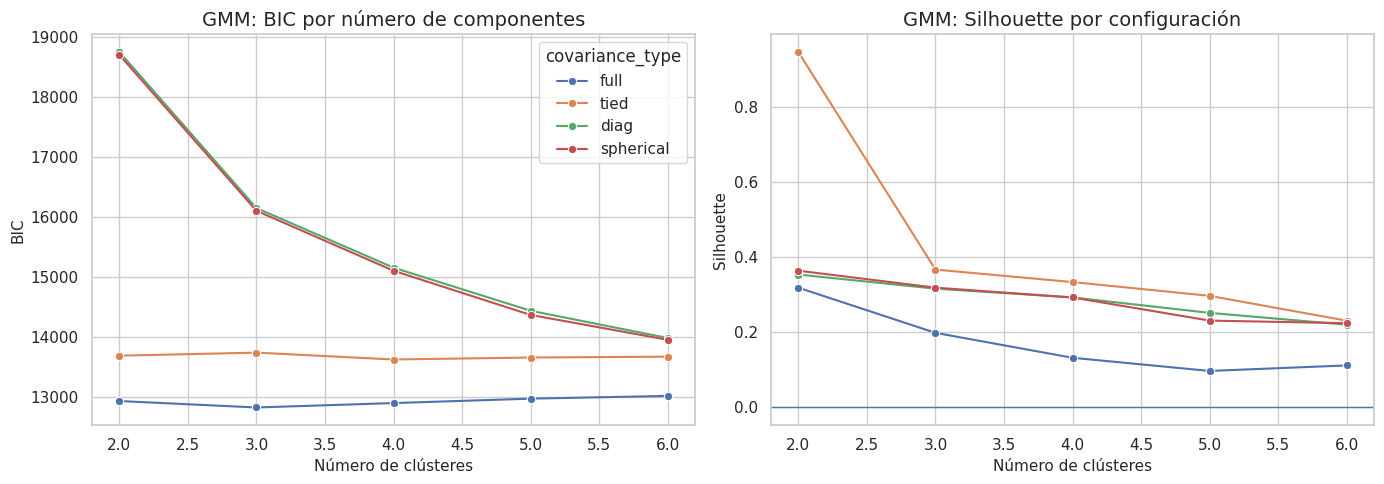

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=gmm_results,
    x="n_clusters",
    y="BIC",
    hue="covariance_type",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("GMM: BIC por número de componentes")
axes[0].set_xlabel("Número de clústeres")

sns.lineplot(
    data=gmm_results,
    x="n_clusters",
    y="Silhouette",
    hue="covariance_type",
    marker="o",
    ax=axes[1],
    legend=False,
)
axes[1].axhline(0, linewidth=1)
axes[1].set_title("GMM: Silhouette por configuración")
axes[1].set_xlabel("Número de clústeres")

plt.tight_layout()
plt.show()

In [14]:
best_gmm_params = gmm_ranked.iloc[0]
gmm_model = GaussianMixture(
    n_components=int(best_gmm_params["n_clusters"]),
    covariance_type=best_gmm_params["covariance_type"],
    n_init=10,
    max_iter=500,
    reg_covar=1e-4,
    random_state=RANDOM_STATE,
)
gmm_labels_raw = gmm_model.fit_predict(X_scaled)
gmm_probabilities = gmm_model.predict_proba(X_scaled)
gmm_max_probability = gmm_probabilities.max(axis=1)

print("Configuración GMM seleccionada:")
print(f"  n_clusters = {int(best_gmm_params['n_clusters'])}")
print(f"  covariance_type = {best_gmm_params['covariance_type']}")
print(f"  convergencia = {gmm_model.converged_}")
print(f"  iteraciones = {gmm_model.n_iter_}")
print(f"  observaciones con probabilidad máxima < 0.65: {(gmm_max_probability < 0.65).sum()}")

Configuración GMM seleccionada:
  n_clusters = 2
  covariance_type = diag
  convergencia = True
  iteraciones = 12
  observaciones con probabilidad máxima < 0.65: 44


El BIC y el AIC se reportan porque son criterios específicos de modelos probabilísticos, pero no se emplean de forma aislada. En este conjunto, algunas configuraciones con BIC favorable generan grupos pequeños o separaciones geométricas débiles. La solución final se elige entre configuraciones no degeneradas mediante el ranking conjunto de las métricas internas, usando BIC como desempate.

### 8.1. Incertidumbre de asignación en GMM

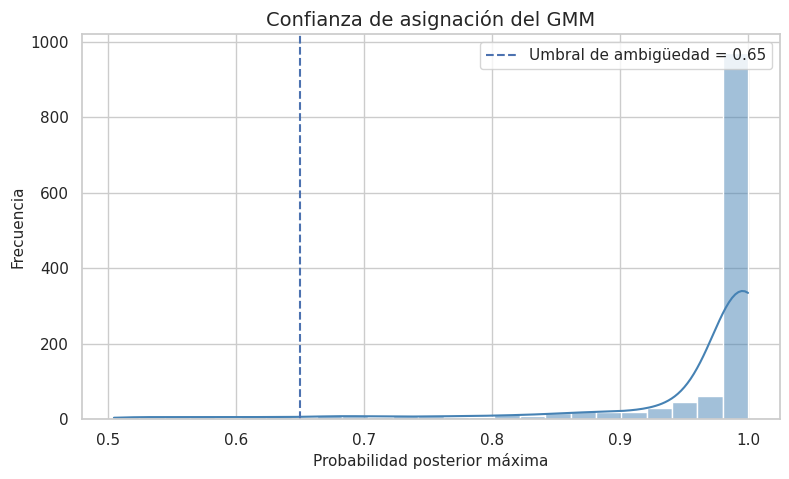

,Country.of.Origin,Variety,Total.Cup.Points,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,GMM_Max_Probability
1058,Colombia,Unknown,80.670,7.170,7.250,7.080,7.420,7.080,7.420,0.504
1131,Mexico,Bourbon,79.920,7.330,7.080,7.080,7.330,7.420,7.170,0.504
1023,Nicaragua,Caturra,80.920,7.330,7.080,7.250,7.000,7.500,7.420,0.504
68,Uganda,SL14,85.500,8.330,7.920,7.670,7.920,7.670,7.920,0.507
1135,Mexico,Typica,79.920,7.330,7.250,7.000,7.420,7.170,7.170,0.511
1067,Taiwan,Other,80.500,7.170,7.170,7.170,7.420,7.170,7.250,0.513
1070,Mauritius,Unknown,80.500,7.250,7.250,7.170,7.170,7.250,7.170,0.518
130,Costa Rica,Caturra,84.670,8.170,8.000,7.830,7.170,7.830,7.750,0.523
860,Vietnam,Caturra,81.750,7.000,7.080,7.330,7.500,7.500,7.330,0.525
1078,Honduras,Unknown,80.420,7.250,7.420,7.000,7.420,7.330,7.000,0.526


In [15]:
plt.figure(figsize=(9, 5))
sns.histplot(gmm_max_probability, bins=25, kde=True, color="steelblue")
plt.axvline(0.65, linestyle="--", label="Umbral de ambigüedad = 0.65")
plt.xlabel("Probabilidad posterior máxima")
plt.ylabel("Frecuencia")
plt.title("Confianza de asignación del GMM")
plt.legend()
plt.show()

ambiguous_idx = np.where(gmm_max_probability < 0.65)[0]
ambiguous_gmm = df.loc[
    ambiguous_idx,
    ["Country.of.Origin", "Variety", "Total.Cup.Points"] + core_features,
].copy()
ambiguous_gmm["GMM_Max_Probability"] = gmm_max_probability[ambiguous_idx]
display(ambiguous_gmm.sort_values("GMM_Max_Probability").head(10))

## 9. Algoritmo 2: Clustering Jerárquico Aglomerativo

In [16]:
agg_rows = []
for n_clusters in range(2, 7):
    for linkage_method in ["ward", "complete", "average", "single"]:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=linkage_method,
        )
        labels = model.fit_predict(X_scaled)
        agg_rows.append({
            "n_clusters": n_clusters,
            "linkage": linkage_method,
            **evaluate_partition(X_scaled, labels),
        })

agg_results = pd.DataFrame(agg_rows)
agg_valid = agg_results[agg_results["Min_Cluster_Size"] >= MIN_CLUSTER_SIZE].copy()
agg_ranked = add_composite_rank(agg_valid)
display(agg_ranked.head(10))

,n_clusters,linkage,Silhouette,Calinski_Harabasz,Davies_Bouldin,Min_Cluster_Size,Max_Cluster_Size,Cluster_Sizes,Rank_Silhouette,Rank_CH,Rank_DB,Rank_Total
0,2,ward,0.389,580.928,0.958,336,974,"(336, 974)",1.000,1.000,1.000,3.000


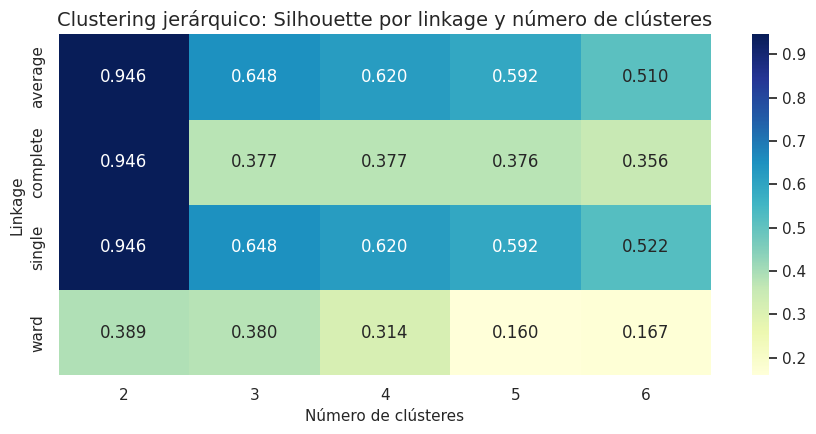

In [17]:
pivot_agg = agg_results.pivot(index="linkage", columns="n_clusters", values="Silhouette")
plt.figure(figsize=(9, 4.5))
sns.heatmap(pivot_agg, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Clustering jerárquico: Silhouette por linkage y número de clústeres")
plt.xlabel("Número de clústeres")
plt.ylabel("Linkage")
plt.tight_layout()
plt.show()

In [18]:
best_agg_params = agg_ranked.iloc[0]
agg_model = AgglomerativeClustering(
    n_clusters=int(best_agg_params["n_clusters"]),
    linkage=best_agg_params["linkage"],
)
agg_labels_raw = agg_model.fit_predict(X_scaled)

print("Configuración jerárquica seleccionada:")
print(f"  n_clusters = {int(best_agg_params['n_clusters'])}")
print(f"  linkage = {best_agg_params['linkage']}")

Configuración jerárquica seleccionada:
  n_clusters = 2
  linkage = ward


### 9.1. Dendrograma

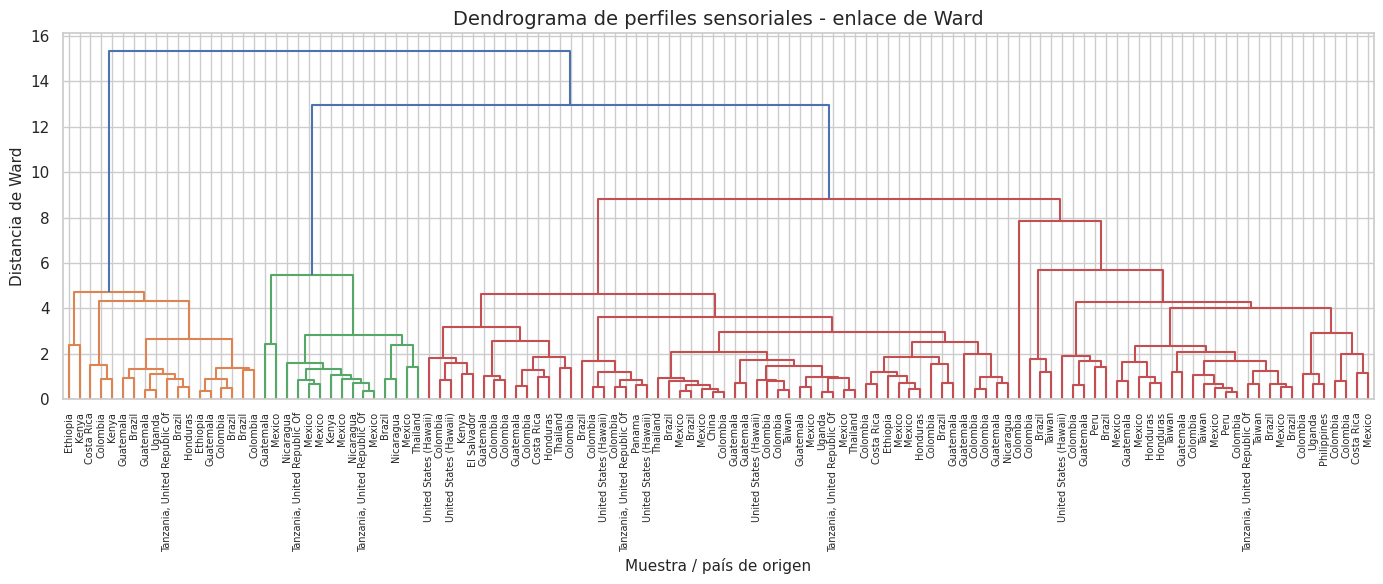

In [19]:
# Se usa una muestra reproducible para mantener el dendrograma legible.
rng = np.random.default_rng(RANDOM_STATE)
sample_size = min(120, len(df))
sample_indices = rng.choice(len(df), size=sample_size, replace=False)
Z = linkage(X_scaled[sample_indices], method="ward")

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    labels=df.loc[sample_indices, "Country.of.Origin"].astype(str).values,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=None,
)
plt.title("Dendrograma de perfiles sensoriales - enlace de Ward")
plt.xlabel("Muestra / país de origen")
plt.ylabel("Distancia de Ward")
plt.tight_layout()
plt.show()

Los linkages `single`, `average` y `complete` pueden producir valores de Silhouette aparentemente altos al aislar una o pocas observaciones. El filtro de tamaño mínimo evita aceptar esas soluciones degeneradas. Ward produce grupos suficientemente grandes y minimiza el incremento de varianza interna en cada fusión.

## 10. Algoritmo 3: Clustering Espectral

In [20]:
spectral_rows = []
for n_clusters in range(2, 6):
    for n_neighbors in [5, 10, 15, 20, 30, 50]:
        for assign_labels in ["kmeans", "discretize"]:
            model = SpectralClustering(
                n_clusters=n_clusters,
                affinity="nearest_neighbors",
                n_neighbors=n_neighbors,
                assign_labels=assign_labels,
                n_init=10,
                random_state=RANDOM_STATE,
            )
            labels = model.fit_predict(X_scaled)
            spectral_rows.append({
                "n_clusters": n_clusters,
                "n_neighbors": n_neighbors,
                "assign_labels": assign_labels,
                **evaluate_partition(X_scaled, labels),
            })

spectral_results = pd.DataFrame(spectral_rows)
spectral_valid = spectral_results[
    spectral_results["Min_Cluster_Size"] >= MIN_CLUSTER_SIZE
].copy()
spectral_ranked = add_composite_rank(spectral_valid)
display(spectral_ranked.head(12))

,n_clusters,n_neighbors,assign_labels,Silhouette,Calinski_Harabasz,Davies_Bouldin,Min_Cluster_Size,Max_Cluster_Size,Cluster_Sizes,Rank_Silhouette,Rank_CH,Rank_DB,Rank_Total
0,2,20,kmeans,0.365,626.934,0.989,490,820,"(820, 490)",4.000,5.000,8.000,17.000
1,2,5,kmeans,0.370,618.099,0.977,441,869,"(441, 869)",1.000,12.000,5.000,18.000
2,2,10,kmeans,0.366,623.675,0.986,474,836,"(474, 836)",2.000,10.000,6.000,18.000
3,2,30,kmeans,0.363,628.038,0.992,503,807,"(807, 503)",6.000,2.000,10.000,18.000
4,2,50,kmeans,0.362,628.579,0.994,512,798,"(798, 512)",7.000,1.000,11.000,19.000
5,2,5,discretize,0.365,621.998,0.987,471,839,"(839, 471)",3.000,11.000,7.000,21.000
6,2,15,kmeans,0.364,626.577,0.991,493,817,"(817, 493)",5.000,7.000,9.000,21.000
7,2,20,discretize,0.361,627.767,0.997,519,791,"(791, 519)",8.000,3.000,12.000,23.000
8,2,30,discretize,0.360,627.442,0.997,523,787,"(787, 523)",10.000,4.000,13.000,27.000
9,2,10,discretize,0.361,626.150,0.997,515,795,"(795, 515)",9.000,9.000,14.000,32.000


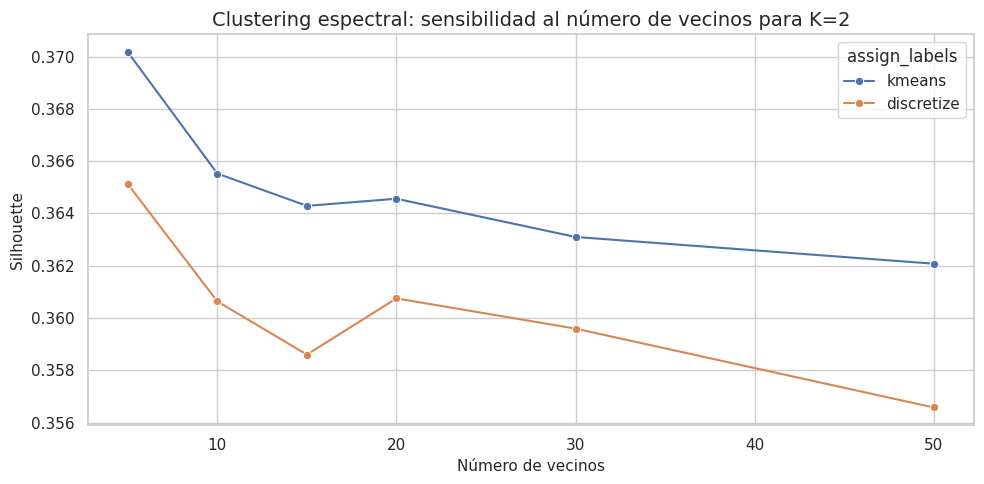

In [21]:
spectral_k2 = spectral_results[spectral_results["n_clusters"] == 2].copy()
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=spectral_k2,
    x="n_neighbors",
    y="Silhouette",
    hue="assign_labels",
    marker="o",
)
plt.title("Clustering espectral: sensibilidad al número de vecinos para K=2")
plt.xlabel("Número de vecinos")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

In [22]:
best_spectral_params = spectral_ranked.iloc[0]
spectral_model = SpectralClustering(
    n_clusters=int(best_spectral_params["n_clusters"]),
    affinity="nearest_neighbors",
    n_neighbors=int(best_spectral_params["n_neighbors"]),
    assign_labels=best_spectral_params["assign_labels"],
    n_init=10,
    random_state=RANDOM_STATE,
)
spectral_labels_raw = spectral_model.fit_predict(X_scaled)

print("Configuración espectral seleccionada:")
print(f"  n_clusters = {int(best_spectral_params['n_clusters'])}")
print(f"  n_neighbors = {int(best_spectral_params['n_neighbors'])}")
print(f"  assign_labels = {best_spectral_params['assign_labels']}")

Configuración espectral seleccionada:
  n_clusters = 2
  n_neighbors = 20
  assign_labels = kmeans


El método espectral construye un grafo de vecinos próximos y agrupa a partir de sus autovectores. La búsqueda compara el tamaño de la vecindad y dos estrategias de discretización. Esto permite evaluar si la estructura local aporta una separación más estable que una partición basada directamente en distancias globales.

## 11. Comparación cuantitativa de los métodos

In [23]:
def reorder_labels_by_profile(labels, dataframe, features):
    '''Reordena etiquetas desde el perfil sensorial medio más bajo al más alto.'''
    tmp = dataframe[features].copy()
    tmp["cluster"] = labels
    order = tmp.groupby("cluster")[features].mean().mean(axis=1).sort_values().index
    mapping = {old_label: new_label for new_label, old_label in enumerate(order)}
    return np.array([mapping[label] for label in labels]), mapping


gmm_labels, gmm_mapping = reorder_labels_by_profile(gmm_labels_raw, df, core_features)
agg_labels, agg_mapping = reorder_labels_by_profile(agg_labels_raw, df, core_features)
spectral_labels, spectral_mapping = reorder_labels_by_profile(spectral_labels_raw, df, core_features)

df["GMM_Cluster"] = gmm_labels
df["Hierarchical_Cluster"] = agg_labels
df["Spectral_Cluster"] = spectral_labels
df["GMM_Max_Probability"] = gmm_max_probability

model_labels = {
    "GMM": gmm_labels,
    "Jerárquico": agg_labels,
    "Espectral": spectral_labels,
}

comparison_rows = []
for name, labels in model_labels.items():
    comparison_rows.append({
        "Método": name,
        **evaluate_partition(X_scaled, labels),
    })

metrics_comparison = pd.DataFrame(comparison_rows)
metrics_comparison["Rank_Silhouette"] = metrics_comparison["Silhouette"].rank(ascending=False, method="min")
metrics_comparison["Rank_CH"] = metrics_comparison["Calinski_Harabasz"].rank(ascending=False, method="min")
metrics_comparison["Rank_DB"] = metrics_comparison["Davies_Bouldin"].rank(ascending=True, method="min")
metrics_comparison["Rank_Total"] = metrics_comparison[["Rank_Silhouette", "Rank_CH", "Rank_DB"]].sum(axis=1)
metrics_comparison = metrics_comparison.sort_values("Rank_Total").reset_index(drop=True)

display(metrics_comparison)
BEST_METHOD = metrics_comparison.iloc[0]["Método"]
print(f"Mejor balance global de métricas: {BEST_METHOD}")

,Método,Silhouette,Calinski_Harabasz,Davies_Bouldin,Min_Cluster_Size,Max_Cluster_Size,Cluster_Sizes,Rank_Silhouette,Rank_CH,Rank_DB,Rank_Total
0,Jerárquico,0.389,580.928,0.958,336,974,"(336, 974)",1.000,2.000,1.000,4.000
1,Espectral,0.365,626.934,0.989,490,820,"(490, 820)",2.000,1.000,2.000,5.000
2,GMM,0.354,78.909,3.142,319,991,"(319, 991)",3.000,3.000,3.000,9.000


Mejor balance global de métricas: Jerárquico


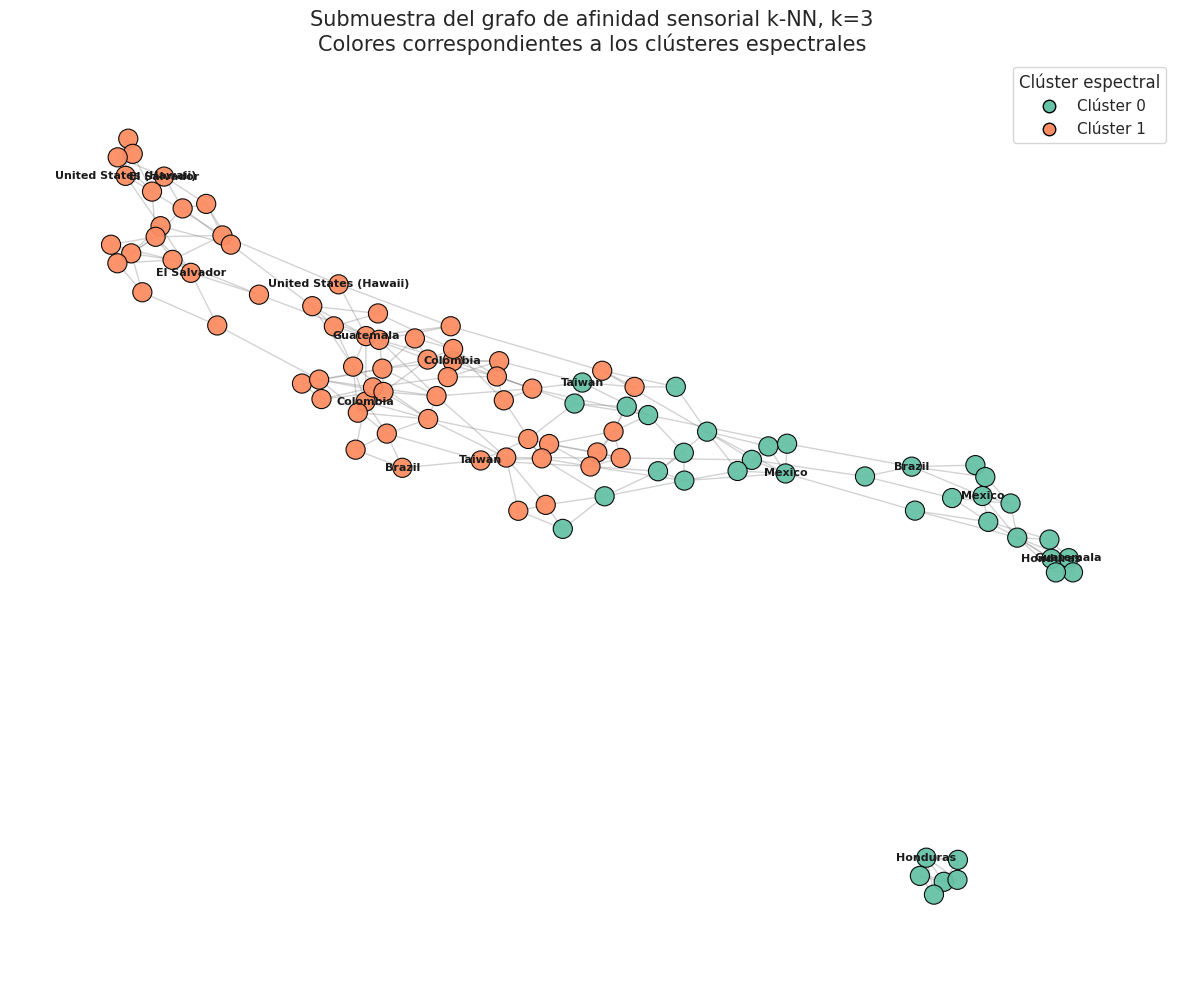

In [33]:
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from matplotlib.lines import Line2D


# ============================================================
# CONFIGURACIÓN DEL GRAFO
# ============================================================

N_NODOS = 100

# Para reproducir visualmente un grafo con k=3:
K_GRAFO = 3

# Para usar el mismo número de vecinos que el modelo seleccionado,
# reemplazar la línea anterior por:
# K_GRAFO = int(best_spectral_params["n_neighbors"])


# ============================================================
# SUBMUESTRA ESTRATIFICADA
# ============================================================

indices = np.arange(len(df))

indices_muestra, _ = train_test_split(
    indices,
    train_size=N_NODOS,
    stratify=spectral_labels,
    random_state=RANDOM_STATE
)

X_grafo = X_scaled[indices_muestra]
clusters_grafo = spectral_labels[indices_muestra]

paises_grafo = (
    df.iloc[indices_muestra]["Country.of.Origin"]
    .fillna("Unknown")
    .astype(str)
    .to_numpy()
)


# ============================================================
# CONSTRUCCIÓN DEL GRAFO k-NN
# ============================================================

matriz_afinidad = kneighbors_graph(
    X_grafo,
    n_neighbors=K_GRAFO,
    mode="connectivity",
    include_self=False
)

# Convertir el grafo dirigido de vecinos en un grafo no dirigido
matriz_afinidad = matriz_afinidad.maximum(matriz_afinidad.T)

grafo = nx.from_scipy_sparse_array(matriz_afinidad)


# ============================================================
# POSICIÓN DE LOS NODOS
# ============================================================

posiciones = nx.spring_layout(
    grafo,
    seed=RANDOM_STATE,
    k=0.55,
    iterations=300
)


# ============================================================
# ETIQUETAS DE PAÍSES
# Se muestran pocos nombres para evitar saturar la figura
# ============================================================

paises_frecuentes = (
    pd.Series(paises_grafo)
    .value_counts()
    .head(8)
    .index
)

etiquetas = {}

for pais in paises_frecuentes:
    nodos_pais = np.where(paises_grafo == pais)[0]

    # Máximo dos etiquetas por país
    for nodo in nodos_pais[:2]:
        etiquetas[int(nodo)] = pais


# ============================================================
# VISUALIZACIÓN
# ============================================================

n_clusters = len(np.unique(clusters_grafo))
paleta = sns.color_palette("Set2", n_colors=n_clusters)

colores_nodos = [
    paleta[int(cluster)]
    for cluster in clusters_grafo
]

plt.figure(figsize=(12, 10))

nx.draw_networkx_edges(
    grafo,
    posiciones,
    edge_color="gray",
    alpha=0.35,
    width=1
)

nx.draw_networkx_nodes(
    grafo,
    posiciones,
    node_color=colores_nodos,
    node_size=190,
    edgecolors="black",
    linewidths=0.8,
    alpha=0.95
)

nx.draw_networkx_labels(
    grafo,
    posiciones,
    labels=etiquetas,
    font_size=8,
    font_weight="bold"
)

elementos_leyenda = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=paleta[i],
        markeredgecolor="black",
        markersize=9,
        label=f"Clúster {i}"
    )
    for i in range(n_clusters)
]

plt.legend(
    handles=elementos_leyenda,
    title="Clúster espectral",
    loc="best"
)

plt.title(
    f"Submuestra del grafo de afinidad sensorial k-NN, k={K_GRAFO}\n"
    "Colores correspondientes a los clústeres espectrales",
    fontsize=15
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    "grafo_afinidad_sensorial.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

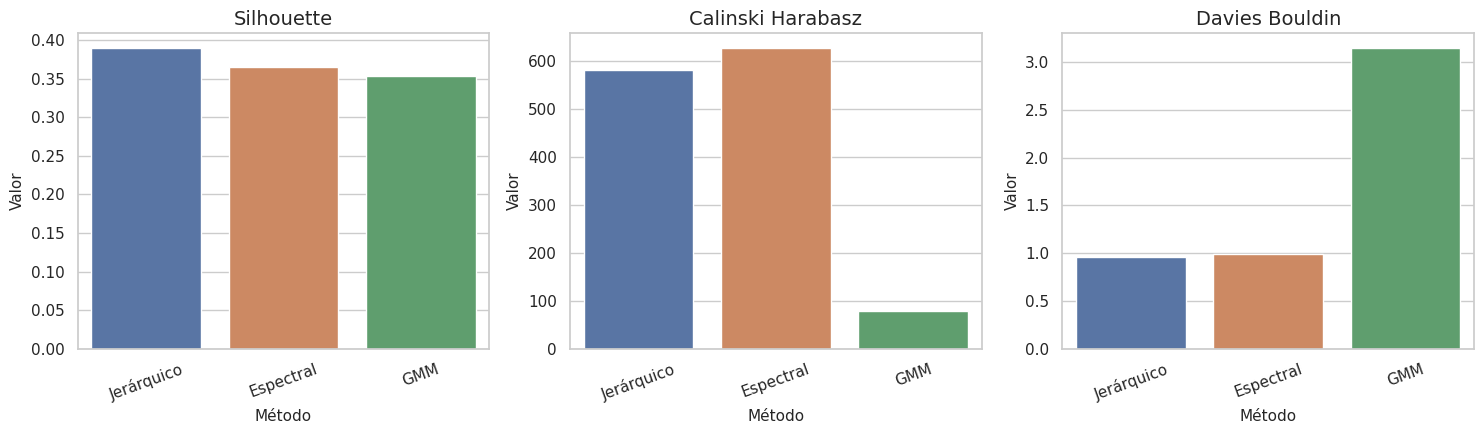

In [24]:
metrics_long = metrics_comparison.melt(
    id_vars="Método",
    value_vars=["Silhouette", "Calinski_Harabasz", "Davies_Bouldin"],
    var_name="Métrica",
    value_name="Valor",
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, ["Silhouette", "Calinski_Harabasz", "Davies_Bouldin"]):
    subset = metrics_long[metrics_long["Métrica"] == metric]
    sns.barplot(data=subset, x="Método", y="Valor", hue="Método", legend=False, ax=ax)
    ax.set_title(metric.replace("_", " "))
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

Silhouette y Davies-Bouldin favorecen particiones compactas y separadas, mientras que Calinski-Harabasz enfatiza la proporción entre dispersión inter e intraclúster. El método ganador se define por el menor ranking agregado, no por una sola cifra. Una diferencia importante es que GMM permite asignaciones probabilísticas, aunque una ventaja conceptual no implica necesariamente una mejor separación geométrica.

### 11.1. Concordancia entre algoritmos

In [25]:
agreement_rows = []
method_names = list(model_labels.keys())
for i in range(len(method_names)):
    for j in range(i + 1, len(method_names)):
        a, b = method_names[i], method_names[j]
        agreement_rows.append({
            "Método_A": a,
            "Método_B": b,
            "Adjusted_Rand_Index": adjusted_rand_score(model_labels[a], model_labels[b]),
            "Normalized_Mutual_Info": normalized_mutual_info_score(model_labels[a], model_labels[b]),
        })

agreement_table = pd.DataFrame(agreement_rows)
display(agreement_table)

,Método_A,Método_B,Adjusted_Rand_Index,Normalized_Mutual_Info
0,GMM,Jerárquico,0.414,0.259
1,GMM,Espectral,0.182,0.115
2,Jerárquico,Espectral,0.574,0.536


ARI y NMI permiten medir si los algoritmos agrupan de manera similar sin depender del número asignado a cada clúster. Una concordancia alta entre dos métodos distintos indica que la separación no es únicamente un artefacto de una arquitectura particular.

## 12. Visualización del espacio de datos

### 12.1. PCA como diagnóstico lineal

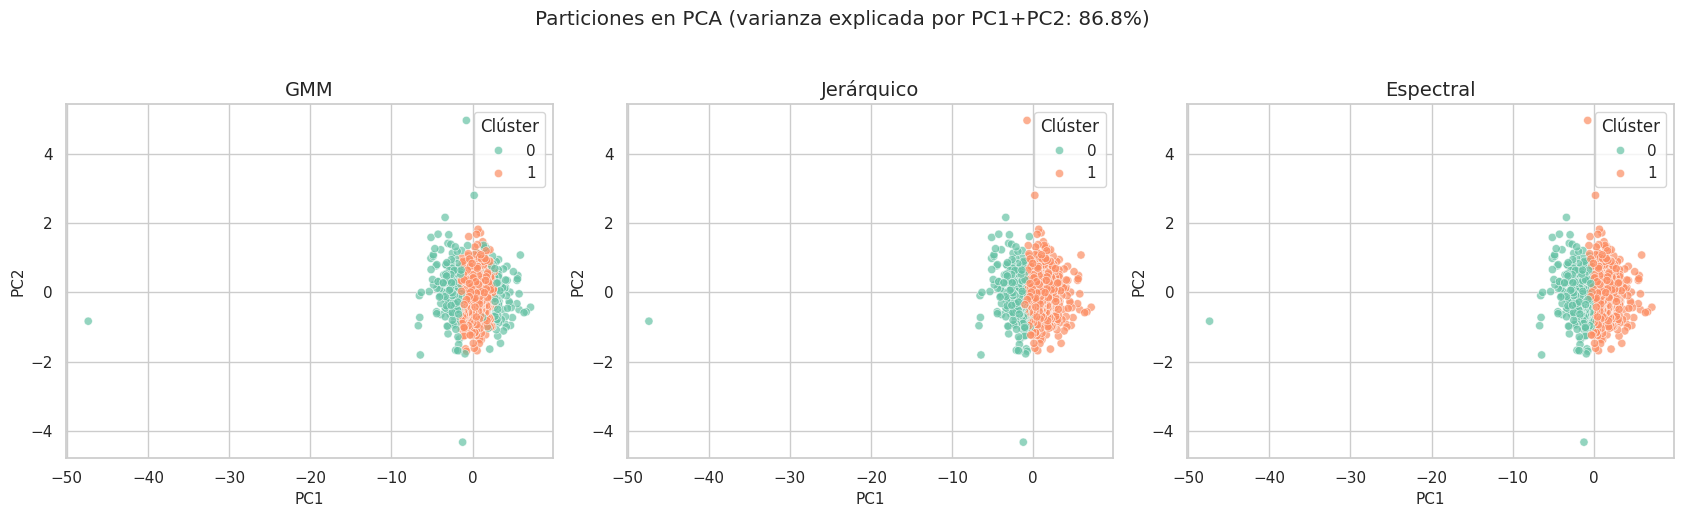

In [26]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
explained = 100 * pca.explained_variance_ratio_.sum()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (name, labels) in zip(axes, model_labels.items()):
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="Set2", alpha=0.7, s=35, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="Clúster")

plt.suptitle(f"Particiones en PCA (varianza explicada por PC1+PC2: {explained:.1f}%)", y=1.03)
plt.tight_layout()
plt.show()

### 12.2. Isomap: visualización no lineal requerida

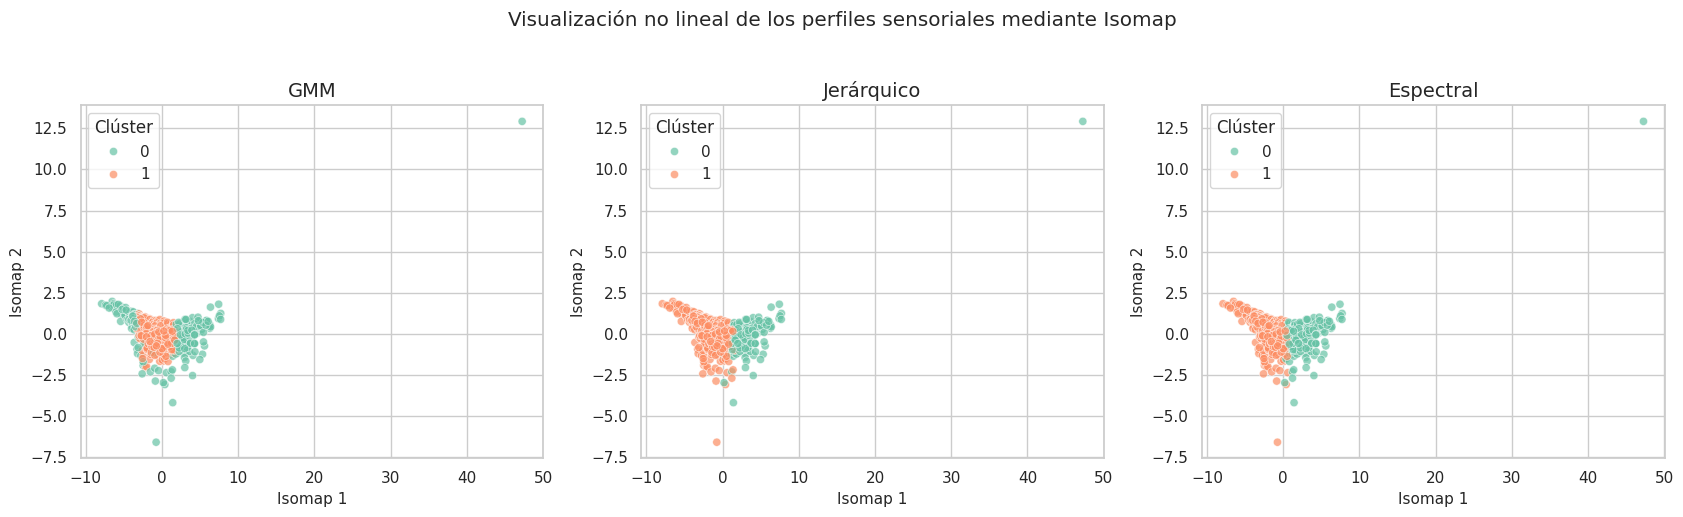

In [27]:
isomap = Isomap(n_neighbors=15, n_components=2)
X_isomap = isomap.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (name, labels) in zip(axes, model_labels.items()):
    sns.scatterplot(x=X_isomap[:, 0], y=X_isomap[:, 1], hue=labels, palette="Set2", alpha=0.7, s=35, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Isomap 1")
    ax.set_ylabel("Isomap 2")
    ax.legend(title="Clúster")

plt.suptitle("Visualización no lineal de los perfiles sensoriales mediante Isomap", y=1.03)
plt.tight_layout()
plt.show()

PCA conserva direcciones lineales de máxima varianza, mientras que Isomap prioriza vecindades locales. Los gráficos se utilizan para inspección visual, no para calcular las métricas ni para entrenar los modelos. Por tanto, una separación aparente en Isomap no se interpreta como evidencia suficiente por sí sola.

## 13. Caracterización e interpretación de los clústeres

In [28]:
cluster_columns = {
    "GMM": "GMM_Cluster",
    "Jerárquico": "Hierarchical_Cluster",
    "Espectral": "Spectral_Cluster",
}

profile_tables = {}
for method, cluster_col in cluster_columns.items():
    profile = df.groupby(cluster_col)[
        core_features + contextual_quality_features
    ].mean()
    profile["Cantidad"] = df.groupby(cluster_col).size()
    profile_tables[method] = profile
    print(f"\nPerfil promedio - {method}")
    display(profile)


Perfil promedio - GMM


,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Total.Cup.Points,Cantidad
GMM_Cluster,,,,,,,,,,,
0,7.422,7.332,7.189,7.386,7.391,7.353,9.652,9.546,9.787,80.382,319
1,7.610,7.578,7.465,7.581,7.559,7.571,9.892,9.925,9.941,82.675,991



Perfil promedio - Jerárquico


,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Total.Cup.Points,Cantidad
Hierarchical_Cluster,,,,,,,,,,,
0,7.242,7.114,6.990,7.192,7.195,7.115,9.666,9.581,9.815,78.999,336
1,7.675,7.658,7.538,7.651,7.629,7.657,9.891,9.920,9.933,83.192,974



Perfil promedio - Espectral


,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Total.Cup.Points,Cantidad
Spectral_Cluster,,,,,,,,,,,
0,7.313,7.213,7.076,7.262,7.269,7.201,9.739,9.680,9.864,79.791,490
1,7.714,7.701,7.590,7.696,7.667,7.707,9.890,9.924,9.927,83.506,820


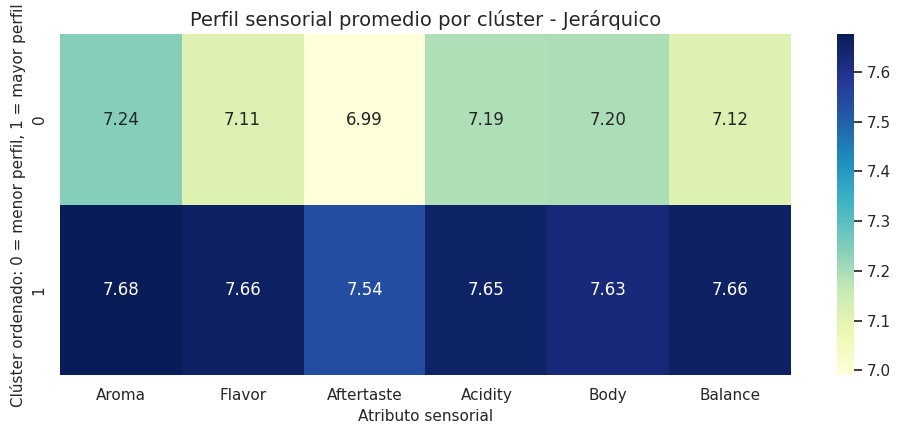

In [29]:
best_cluster_col = cluster_columns[BEST_METHOD]
best_profile = df.groupby(best_cluster_col)[core_features].mean()

plt.figure(figsize=(10, 4.5))
sns.heatmap(best_profile, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Perfil sensorial promedio por clúster - {BEST_METHOD}")
plt.xlabel("Atributo sensorial")
plt.ylabel("Clúster ordenado: 0 = menor perfil, 1 = mayor perfil")
plt.tight_layout()
plt.show()

Las etiquetas fueron reordenadas después del entrenamiento para que el clúster 0 corresponda al perfil sensorial promedio más bajo y el clúster 1 al más alto. Este reordenamiento sólo facilita la lectura; no modifica la partición obtenida.

### 13.1. Validación contextual con Total Cup Points

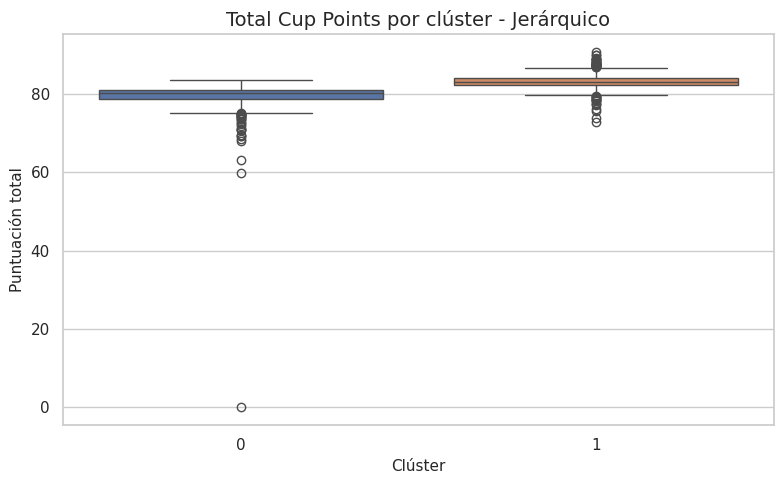

Kruskal-Wallis H = 635.519
p-value = 3.151e-140
                      count   mean  median   std
Hierarchical_Cluster                            
0                       336 78.999  80.080 5.206
1                       974 83.192  83.080 1.671


In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x=best_cluster_col,
    y="Total.Cup.Points",
    hue=best_cluster_col,
    legend=False,
)
plt.title(f"Total Cup Points por clúster - {BEST_METHOD}")
plt.xlabel("Clúster")
plt.ylabel("Puntuación total")
plt.tight_layout()
plt.show()

groups_total = [
    group["Total.Cup.Points"].values
    for _, group in df.groupby(best_cluster_col)
]
kruskal_stat, kruskal_p = kruskal(*groups_total)
print(f"Kruskal-Wallis H = {kruskal_stat:.3f}")
print(f"p-value = {kruskal_p:.3e}")
print(df.groupby(best_cluster_col)["Total.Cup.Points"].agg(["count", "mean", "median", "std"]))

`Total.Cup.Points` no intervino en la formación de los clústeres. Su diferencia posterior entre grupos funciona como validación contextual: una separación clara sugiere que la estructura descubierta a partir de seis atributos sensoriales también se refleja en la evaluación global. El test de Kruskal-Wallis se interpreta como evidencia de diferencias distributivas, no como prueba de causalidad.

### 13.2. Distribución geográfica

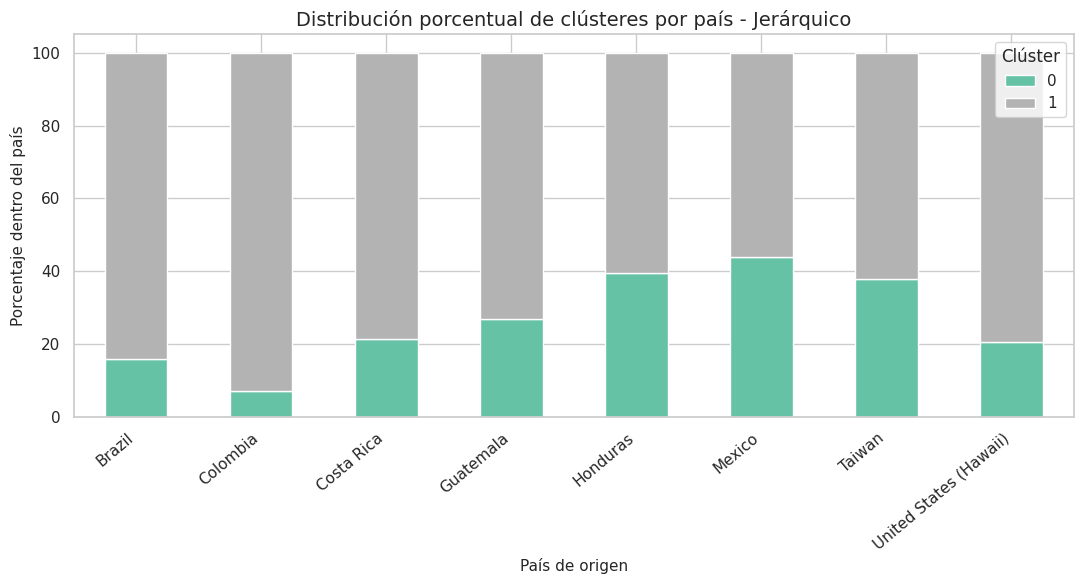

Hierarchical_Cluster,0,1
Country.of.Origin,,
Brazil,15.909,84.091
Colombia,7.104,92.896
Costa Rica,21.569,78.431
Guatemala,27.072,72.928
Honduras,39.623,60.377
Mexico,44.068,55.932
Taiwan,37.838,62.162
United States (Hawaii),20.548,79.452


In [31]:
top_countries = df["Country.of.Origin"].value_counts().head(8).index
geo_subset = df[df["Country.of.Origin"].isin(top_countries)].copy()
geo_distribution = pd.crosstab(
    geo_subset["Country.of.Origin"],
    geo_subset[best_cluster_col],
    normalize="index",
) * 100

geo_distribution.plot(kind="bar", stacked=True, figsize=(11, 6), colormap="Set2")
plt.title(f"Distribución porcentual de clústeres por país - {BEST_METHOD}")
plt.xlabel("País de origen")
plt.ylabel("Porcentaje dentro del país")
plt.xticks(rotation=40, ha="right")
plt.legend(title="Clúster")
plt.tight_layout()
plt.show()

display(geo_distribution)

La distribución por país se utiliza de forma descriptiva. Un país puede concentrar una mayor proporción de determinado perfil, pero el dataset no constituye una muestra aleatoria de toda su producción. Por ello, no se deben generalizar los resultados a la calidad nacional del café sin información adicional sobre muestreo, regiones, cosechas y procesos.

## 14. Discusión crítica

1. **La estructura dominante es principalmente ordinal.** Los modelos tienden a separar cafés con perfiles sensoriales globalmente más altos de cafés con puntuaciones menores. No aparecen categorías completamente independientes de aroma, acidez o cuerpo; las variables evolucionan de manera correlacionada.

2. **El clustering jerárquico ofrece el mejor equilibrio global.** Ward produce grupos compactos, evita clústeres diminutos y obtiene el mejor ranking combinado de métricas internas. Además, el dendrograma permite inspeccionar la estructura a distintas escalas.

3. **El clustering espectral es competitivo.** Su partición presenta una concordancia relevante con la jerárquica y buenos valores de Calinski-Harabasz. Esto sugiere que la separación también está presente en relaciones locales del espacio sensorial.

4. **GMM aporta incertidumbre, pero no necesariamente la mejor geometría.** Su principal ventaja es la probabilidad posterior de pertenencia, útil para detectar cafés transicionales. Sin embargo, la hipótesis de mezcla gaussiana no representa tan bien la estructura como Ward o el método espectral en este conjunto.

5. **El efecto techo debe considerarse.** `Uniformity`, `Clean.Cup` y `Sweetness` se excluyeron del entrenamiento para evitar que desviaciones poco frecuentes respecto de 10 dominaran las distancias. Aun así, se conservaron para describir los grupos.

6. **Limitaciones.** Las puntuaciones provienen de evaluaciones sensoriales y pueden contener variabilidad entre catadores. El dataset no incluye una etiqueta externa de clase ni garantiza representatividad geográfica. Isomap es una herramienta visual y no preserva todas las distancias globales.

## 15. Conclusiones

El análisis identifica dos perfiles sensoriales principales en los cafés arábica del conjunto CQI: un grupo con puntuaciones consistentemente más altas en aroma, sabor, postgusto, acidez, cuerpo y balance, y otro grupo con valores medios menores y mayor presencia de lotes de calidad transicional.

La comparación de hiperparámetros y métricas internas muestra que el **clustering jerárquico con enlace de Ward** ofrece la solución más equilibrada. El **clustering espectral** obtiene resultados cercanos y confirma parcialmente la misma estructura desde una perspectiva de vecindad local. El **GMM** presenta una separación menos favorable, pero aporta información adicional mediante probabilidades de pertenencia y permite identificar observaciones ambiguas.

El resultado más importante no es una métrica aislada, sino la convergencia entre evaluación cuantitativa, visualización e interpretación sensorial. La solución obtenida es útil como segmentación exploratoria, aunque no debe interpretarse como una clasificación oficial de calidad ni como una comparación causal entre países.

## 16. Exportación de resultados reproducibles

In [32]:
metrics_comparison.to_csv("metrics_comparison.csv", index=False)
agreement_table.to_csv("cluster_agreement.csv", index=False)
gmm_results.to_csv("gmm_tuning_results.csv", index=False)
agg_results.to_csv("agglomerative_tuning_results.csv", index=False)
spectral_results.to_csv("spectral_tuning_results.csv", index=False)
df.to_csv("coffee_clusters_results.csv", index=False)

print("Archivos generados:")
for filename in [
    "metrics_comparison.csv",
    "cluster_agreement.csv",
    "gmm_tuning_results.csv",
    "agglomerative_tuning_results.csv",
    "spectral_tuning_results.csv",
    "coffee_clusters_results.csv",
]:
    print(" -", filename)

Archivos generados:
 - metrics_comparison.csv
 - cluster_agreement.csv
 - gmm_tuning_results.csv
 - agglomerative_tuning_results.csv
 - spectral_tuning_results.csv
 - coffee_clusters_results.csv


## 17. Referencias

- Coffee Quality Database. *Arabica Coffee Quality Data*. Repositorio público: https://github.com/jldbc/coffee-quality-database
- McLachlan, G. J., & Peel, D. (2000). *Finite Mixture Models*. Wiley.
- Ward, J. H. (1963). Hierarchical Grouping to Optimize an Objective Function. *Journal of the American Statistical Association*, 58(301), 236-244.
- Ng, A. Y., Jordan, M. I., & Weiss, Y. (2002). On Spectral Clustering: Analysis and an Algorithm. *Advances in Neural Information Processing Systems*, 14.
- Tenenbaum, J. B., de Silva, V., & Langford, J. C. (2000). A Global Geometric Framework for Nonlinear Dimensionality Reduction. *Science*, 290(5500), 2319-2323.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.